In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 Nano model
model = YOLO("yolov8n.pt")

WARNING Corrupt cache yolov8n.pt, re-downloading yolov8n.pt...


In [4]:
image_path = "sample.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Image not found.")
else:
    print("Image Loaded Successfully!")

Image Loaded Successfully!


In [5]:
results = model(image)

annotated_image = results[0].plot()

print("Objects Detected:\n")

for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    print(f"{model.names[cls]} : {conf:.2f}")


0: 640x320 4 cars, 529.2ms
Speed: 28.7ms preprocess, 529.2ms inference, 48.0ms postprocess per image at shape (1, 3, 640, 320)
Objects Detected:

car : 0.89
car : 0.83
car : 0.71
car : 0.64


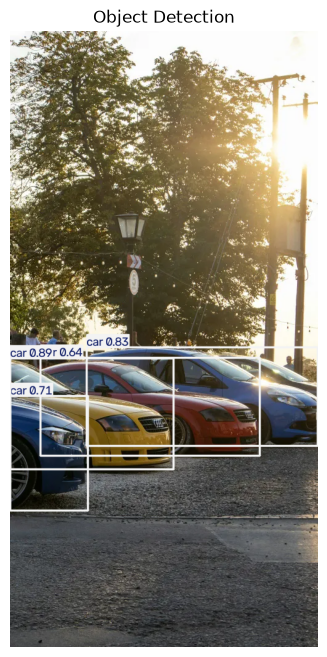

Output image saved as output.jpg


In [6]:
annotated_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Object Detection")
plt.show()

cv2.imwrite("output.jpg", annotated_image)

print("Output image saved as output.jpg")